# 05 - Gain Analysis: Ensemble Benefit vs History Length

**Câu hỏi nghiên cứu:** Lợi ích của việc kết hợp GB + pretrained
model có phụ thuộc vào độ dài lịch sử dữ liệu (cold-start vs
long-history) hay không?

**Giả thuyết (H1):** Ensemble có lợi rõ rệt hơn ở series cold-start,
vì pretrained model bù đắp cho việc GB thiếu dữ liệu để học lag
features tốt.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from evaluation import smape_per_series
from stats_analysis import (
    compute_gain, attach_metadata, kruskal_test,
    mannwhitney_test, summarize_gain_by_group
)

## Bước 1 — Load dữ liệu

In [2]:
ensemble_df = pd.read_csv("../outputs/metrics/ensemble_predictions.csv")
sampled_metadata = pd.read_csv("../data/processed/sampled_metadata.csv")

print(f"Số dòng: {len(ensemble_df)}, số series: {ensemble_df['unique_id'].nunique()}")
ensemble_df.head()

Số dòng: 8334, số series: 463


,unique_id,length_group,category,ds,y,pred_gb,pred_pretrained,pred_ensemble_avg,pred_ensemble_weighted
0,M10200,short,Micro,1907-11-01,1381.0,1388.933419,1377.0618,1382.997610,1387.152676
1,M10200,short,Micro,1907-12-01,1392.0,1392.671706,1372.3296,1382.500653,1389.620390
2,M10200,short,Micro,1908-01-01,1379.0,1389.531443,1372.3296,1380.930521,1386.951166
3,M10200,short,Micro,1908-02-01,1379.0,1391.965168,1362.8652,1377.415184,1387.600173
4,M10200,short,Micro,1908-03-01,1381.0,1388.933419,1362.8652,1375.899310,1385.023186


## Bước 2 — Tính Ensemble Gain theo từng series

Gain = sMAPE(GB) - sMAPE(Ensemble weighted).
Gain > 0 nghĩa là ensemble tốt hơn GB đơn lẻ.

In [3]:
gain_df = compute_gain(
    ensemble_df,
    y_col="y",
    baseline_col="pred_gb",
    ensemble_col="pred_ensemble_weighted"
)

gain_df = attach_metadata(gain_df, sampled_metadata)

print(f"Số series có Gain tính được: {gain_df['gain'].notna().sum()} / {len(gain_df)}")
gain_df.head()

Số series có Gain tính được: 463 / 463


,unique_id,smape_baseline,smape_ensemble,gain,length_group,category
0,M10200,0.983215,0.961460,0.021755,short,Micro
1,M10216,8.856495,7.897707,0.958788,short,Micro
2,M10390,1.498709,1.392040,0.106670,medium,Micro
3,M10405,15.133875,14.610651,0.523224,medium,Micro
4,M10438,8.260734,8.352684,-0.091950,cold_start,Micro


## Bước 3 — Thống kê tổng quan Gain theo length_group

In [4]:
summary = summarize_gain_by_group(gain_df)
print(summary)

# Số series có Gain dương (ensemble thắng) theo từng nhóm
win_rate = gain_df.groupby("length_group", observed=True)["gain"].apply(
    lambda x: (x > 0).mean() * 100
).round(1)
print("\n% series mà Ensemble tốt hơn GB (Gain > 0):")
print(win_rate)

               mean  median    std  count
length_group                             
cold_start   -0.155   0.177  1.865    104
long_history  0.612   0.166  1.293    119
medium       -0.018   0.036  0.786    120
short         0.146   0.083  1.245    120

% series mà Ensemble tốt hơn GB (Gain > 0):
length_group
cold_start      55.8
long_history    80.7
medium          56.7
short           60.0
Name: gain, dtype: float64


## Bước 3b — Kiểm tra riêng sMAPE(GB) vs sMAPE(Pretrained) theo length_group

Kiểm tra giả định nền tảng của giả thuyết: liệu Pretrained model
(Chronos) có thực sự vượt trội hơn GB ở nhóm cold_start hay không —
đây là điều kiện cần để ensemble phát huy tác dụng ở nhóm này.

In [5]:
smape_gb = smape_per_series(ensemble_df, "y", "pred_gb").rename("smape_gb")
smape_pretrained = smape_per_series(ensemble_df, "y", "pred_pretrained").rename("smape_pretrained")

compare_df = pd.concat([smape_gb, smape_pretrained], axis=1).reset_index()
compare_df = compare_df.rename(columns={"index": "unique_id"})
compare_df = attach_metadata(compare_df, sampled_metadata)

# Thống kê trung bình/trung vị sMAPE của từng model theo length_group
summary_compare = compare_df.groupby("length_group", observed=True)[
    ["smape_gb", "smape_pretrained"]
].agg(['mean', 'median']).round(3)
print("So sánh sMAPE trung bình/trung vị — GB vs Pretrained theo length_group:")
print(summary_compare)

# % series mà Pretrained thắng GB (sMAPE thấp hơn = tốt hơn)
compare_df["pretrained_better"] = compare_df["smape_pretrained"] < compare_df["smape_gb"]
win_rate_pretrained = (
    compare_df.groupby("length_group", observed=True)["pretrained_better"].mean() * 100
).round(1)
print("\n% series mà Pretrained tốt hơn GB (sMAPE thấp hơn):")
print(win_rate_pretrained)

So sánh sMAPE trung bình/trung vị — GB vs Pretrained theo length_group:
             smape_gb         smape_pretrained        
                 mean  median             mean  median
length_group                                          
cold_start     15.571  11.265           22.482  19.253
long_history    7.434   2.044            5.506   1.982
medium          4.685   2.603            7.672   3.978
short          10.338   5.773           13.456   9.517

% series mà Pretrained tốt hơn GB (sMAPE thấp hơn):
length_group
cold_start      29.8
long_history    52.1
medium          26.7
short           29.2
Name: pretrained_better, dtype: float64


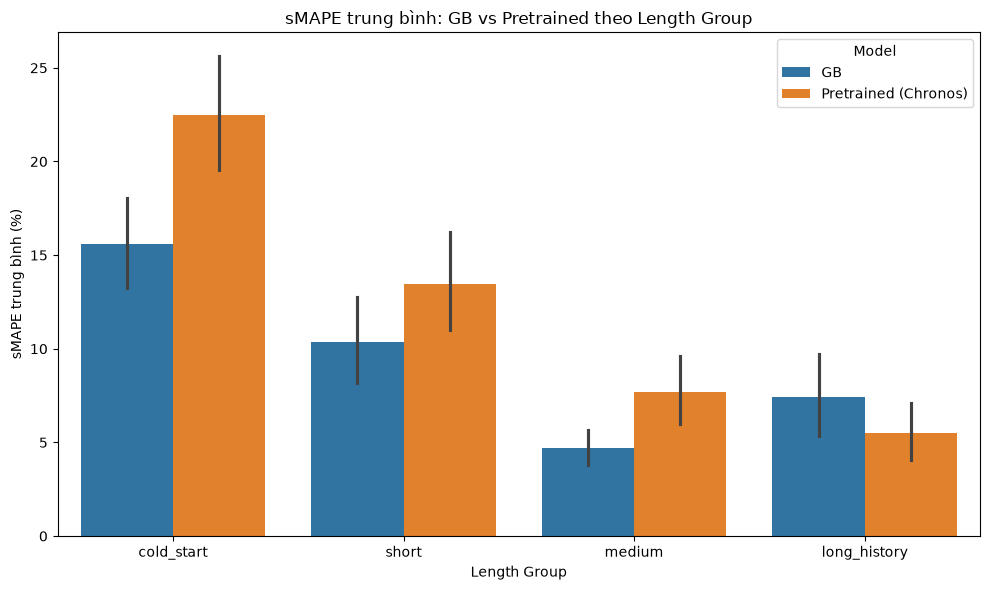

In [6]:
order = ["cold_start", "short", "medium", "long_history"]

plot_data = compare_df.melt(
    id_vars=["length_group"],
    value_vars=["smape_gb", "smape_pretrained"],
    var_name="model", value_name="smape"
)
plot_data["model"] = plot_data["model"].map({
    "smape_gb": "GB", "smape_pretrained": "Pretrained (Chronos)"
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data, x="length_group", y="smape", hue="model",
    order=order, estimator="mean", errorbar=("ci", 95)
)
plt.title("sMAPE trung bình: GB vs Pretrained theo Length Group")
plt.xlabel("Length Group")
plt.ylabel("sMAPE trung bình (%)")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import wilcoxon

print("Wilcoxon signed-rank test: sMAPE(GB) vs sMAPE(Pretrained) theo từng length_group")
print("H1 (one-sided): GB có sMAPE THẤP HƠN Pretrained (GB tốt hơn)\n")

for group in order:
    subset = compare_df[compare_df["length_group"] == group]
    stat, p = wilcoxon(subset["smape_gb"], subset["smape_pretrained"],
                        alternative="less")
    print(f"{group}: n={len(subset)}, statistic={stat:.1f}, p_value={p:.4f}"
          f" {'=> GB tốt hơn có ý nghĩa (p<0.05)' if p < 0.05 else '=> chưa đủ ý nghĩa TK'}")

Wilcoxon signed-rank test: sMAPE(GB) vs sMAPE(Pretrained) theo từng length_group
H1 (one-sided): GB có sMAPE THẤP HƠN Pretrained (GB tốt hơn)

cold_start: n=104, statistic=1293.0, p_value=0.0000 => GB tốt hơn có ý nghĩa (p<0.05)
short: n=120, statistic=1864.0, p_value=0.0000 => GB tốt hơn có ý nghĩa (p<0.05)
medium: n=120, statistic=1617.0, p_value=0.0000 => GB tốt hơn có ý nghĩa (p<0.05)
long_history: n=119, statistic=4168.0, p_value=0.9436 => chưa đủ ý nghĩa TK


## Bước 4 — Trực quan hóa: Boxplot Gain theo length_group

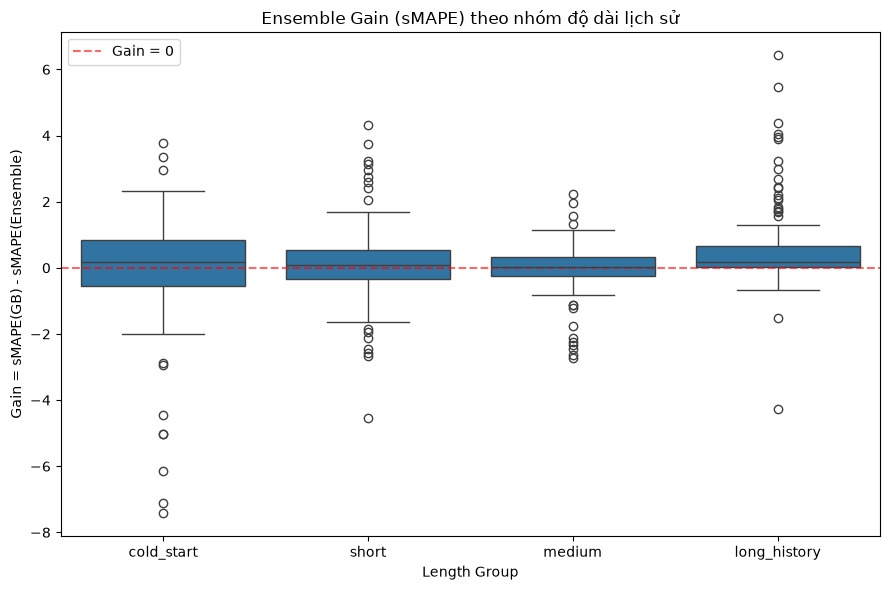

In [8]:
order = ["cold_start", "short", "medium", "long_history"]

plt.figure(figsize=(9, 6))
sns.boxplot(data=gain_df, x="length_group", y="gain", order=order)
plt.axhline(0, color="red", linestyle="--", alpha=0.6, label="Gain = 0")
plt.title("Ensemble Gain (sMAPE) theo nhóm độ dài lịch sử")
plt.xlabel("Length Group")
plt.ylabel("Gain = sMAPE(GB) - sMAPE(Ensemble)")
plt.legend()
plt.tight_layout()
plt.show()

## Bước 5 — Kiểm định thống kê

### 5a. Kruskal-Wallis: so sánh cả 4 nhóm cùng lúc

In [9]:
kw_result = kruskal_test(gain_df, group_col="length_group", value_col="gain")
print("Kruskal-Wallis test (4 nhóm length_group):")
print(kw_result)

if kw_result["p_value"] < 0.05:
    print("\n=> Có sự khác biệt có ý nghĩa thống kê giữa các nhóm (p < 0.05)")
else:
    print("\n=> Không đủ bằng chứng để nói các nhóm khác nhau (p >= 0.05)")

Kruskal-Wallis test (4 nhóm length_group):
{'statistic': np.float64(17.985639899783337), 'p_value': np.float64(0.0004428593775282531)}

=> Có sự khác biệt có ý nghĩa thống kê giữa các nhóm (p < 0.05)


### 5b. Mann-Whitney U test: so sánh trực tiếp cold_start vs long_history

Đây là kiểm định trực tiếp cho giả thuyết chính của đề tài.

In [10]:
mw_result = mannwhitney_test(
    gain_df, group_col="length_group", value_col="gain",
    group_a="cold_start", group_b="long_history"
)

print("Mann-Whitney U test (cold_start vs long_history, one-sided: cold_start > long_history):")
for k, v in mw_result.items():
    print(f"  {k}: {v}")

if mw_result["p_value"] < 0.05:
    print("\n=> Ủng hộ giả thuyết: Gain ở cold_start LỚN HƠN long_history có ý nghĩa thống kê (p < 0.05)")
else:
    print("\n=> Chưa đủ bằng chứng thống kê để khẳng định giả thuyết (p >= 0.05)")

Mann-Whitney U test (cold_start vs long_history, one-sided: cold_start > long_history):
  statistic: 5129.0
  p_value: 0.9862495727444667
  median_cold_start: 0.17682968680423894
  median_long_history: 0.1664586630094873
  n_cold_start: 104
  n_long_history: 119

=> Chưa đủ bằng chứng thống kê để khẳng định giả thuyết (p >= 0.05)


## Bước 6 — Lưu kết quả Gain (dùng cho báo cáo và 06_shap_case_study.ipynb)

In [11]:
gain_df.to_csv("../outputs/metrics/gain_analysis_results.csv", index=False)
summary.to_csv("../outputs/metrics/gain_summary_by_group.csv")

print("Đã lưu gain_analysis_results.csv và gain_summary_by_group.csv")

Đã lưu gain_analysis_results.csv và gain_summary_by_group.csv


## Kết luận

Kết quả không ủng hộ giả thuyết ban đầu về cold-start. Phân tích sâu
hơn (so sánh sMAPE riêng GB vs Pretrained) cho thấy NGUYÊN NHÂN gốc
rễ: giả định nền tảng của giả thuyết — "pretrained model mạnh hơn GB
khi thiếu dữ liệu" — KHÔNG đúng với thiết lập thí nghiệm này. Ngược
lại, GB (huấn luyện pooled trên nhiều series cùng lúc) vượt trội hơn
Chronos-t5-small (zero-shot) ở MỌI length_group ngoại trừ
long_history, nơi 2 model gần tương đương.

Vì Ensemble chỉ có lợi khi 2 model đủ mạnh và bổ sung cho nhau, việc
kết hợp GB với một Pretrained model yếu hơn ở cold_start không mang
lại cải thiện — thậm chí có xu hướng kéo kết quả xuống nhẹ, đúng như
Gain trung bình âm quan sát được ở nhóm này.

Điều này gợi ý một phát hiện quan trọng hơn phạm vi giả thuyết ban
đầu: lợi ích của ensemble phụ thuộc vào SỨC MẠNH TƯƠNG ĐỐI giữa 2
model tại từng nhóm dữ liệu, không chỉ đơn thuần phụ thuộc vào độ
dài lịch sử. Cơ chế "pretrained bù đắp cho GB thiếu dữ liệu" chỉ
đúng khi pretrained model thực sự đủ mạnh — điều không xảy ra với
Chronos-t5-small (bản nhỏ nhất) trên dataset M4 Monthly này.